## Prelab 10 - Amanda Chang

In [5]:
import pandas as pd
import csv
import math
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.signal import find_peaks
import numpy as np
pd.set_option('display.float_format', lambda x: '%e' % x)

TITLE_FONTSIZE = 14
AXES_FONTSIZE = 12

def process_digilent(filename):
    """
    Reads a Digilent WaveForms CSV file and returns a cleaned pandas DataFrame.
    Automatically skips metadata lines starting with '#'.
    """
    file_path = "data/execution/Execution_"+filename+".csv"
    df = pd.read_csv(file_path, comment='#')
    return df

def plot_bode_cutoff(filename, title="Bode Plot"):
    df = process_digilent(filename)
    
    freq  = df['Frequency (Hz)']
    mag   = df['Channel 2 Magnitude (dB)']
    phase = df['Channel 2 Phase (deg)']
    phase_unwrapped = np.rad2deg(np.unwrap(np.deg2rad(phase)))

    # --- -3dB cutoff ---
    dc_gain = mag.iloc[0]
    target  = dc_gain - 3
    signs   = np.sign(mag - target)
    crossings = np.where(np.diff(signs))[0]
    if len(crossings) == 0:
        raise ValueError("No -3dB crossing found in data.")
    i = crossings[0]
    f0, f1 = freq.iloc[i], freq.iloc[i + 1]
    m0, m1 = mag.iloc[i], mag.iloc[i + 1]
    cutoff_freq = f0 + (f1 - f0) * (target - m0) / (m1 - m0)

    # --- plot ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    # magnitude plot
    ax1.semilogx(freq, mag, color='blue', linewidth=1.5)
    ax1.axhline(0,      color='gray',  linestyle=':',  linewidth=1.0)
    ax1.axhline(target, color='gray',  linestyle=':',  linewidth=1.0)
    ax1.axvline(cutoff_freq, color='purple', linestyle='--', linewidth=1.2,
                label=f'$f_{{-3dB}}$ = {cutoff_freq:.1f} Hz')
    ax1.plot(cutoff_freq, target, 'o', color='purple', markersize=7)
    ax1.set_ylabel('Magnitude (dB)')
    ax1.set_title(title)
    ax1.grid(True, which="both", ls="-", alpha=0.5)
    ax1.legend()

    # phase plot
    ax2.semilogx(freq, phase_unwrapped, color='red', linewidth=1.5)
    ax2.axhline(-180, color='gray', linestyle=':', linewidth=1.0)
    ax2.axvline(cutoff_freq, color='purple', linestyle='--', linewidth=1.2,
                label=f'$f_{{-3dB}}$ = {cutoff_freq:.1f} Hz')
    ax2.set_xlabel('Frequency (Hz)')
    ax2.set_ylabel('Phase (deg)')
    ax2.grid(True, which="both", ls="-", alpha=0.5)
    ax2.legend()

    plt.tight_layout()
    plt.show()

    print(f"Closed-loop -3dB cutoff : {cutoff_freq:.4f} Hz")
    
    return cutoff_freq

def plot_bode(filename, wgc=None, title="Bode Plot", gain_margin=False, cutoff=False):
    df = process_digilent(filename)
    
    freq  = df['Frequency (Hz)']
    mag   = df['Channel 2 Magnitude (dB)']
    phase = df['Channel 2 Phase (deg)']
    phase_unwrapped = np.rad2deg(np.unwrap(np.deg2rad(phase)))

    # --- gain crossover frequency (0 dB crossing) ---
    if wgc is None:
        signs = np.sign(mag)
        sign_changes = np.where(np.diff(signs))[0]
        if len(sign_changes) == 0:
            raise ValueError("No gain crossover (0 dB crossing) found in data.")
        i = sign_changes[0]
        f0, f1 = freq.iloc[i], freq.iloc[i + 1]
        m0, m1 = mag.iloc[i],  mag.iloc[i + 1]
        wgc = f0 + (f1 - f0) * (-m0) / (m1 - m0)

    idx          = (freq - wgc).abs().idxmin()
    wgc_freq     = freq.loc[idx]
    wgc_mag      = mag.loc[idx]
    wgc_phase    = phase_unwrapped[idx]
    phase_margin = 180 + wgc_phase

    # --- phase crossover frequency (-180 deg crossing) ---
    if gain_margin == True:
        signs_ph = np.sign(phase_unwrapped + 180)
        ph_crossings = np.where(np.diff(signs_ph))[0]
        if len(ph_crossings) == 0:
            gain_margin_db = None
            gain_margin_hz = None
        else:
            i = ph_crossings[0]
            f0, f1 = freq.iloc[i], freq.iloc[i + 1]
            p0, p1 = phase_unwrapped[i], phase_unwrapped[i + 1]
            gain_margin_hz = f0 + (f1 - f0) * (-180 - p0) / (p1 - p0)  # interpolate on phase
            gm_idx = (freq - gain_margin_hz).abs().idxmin()
            gain_margin_db = -mag.loc[gm_idx]  # GM = how far below 0 dB (positive = stable)

    # --- plot ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    # magnitude plot
    ax1.semilogx(freq, mag, color='blue', linewidth=1.5)
    ax1.axvline(wgc_freq, color='green', linestyle='--', linewidth=1.2,
                label=f'$f_{{gc}}$ = {wgc_freq:.1f} Hz')
    ax1.axhline(0, color='gray', linestyle=':', linewidth=1.0)
    ax1.plot(wgc_freq, wgc_mag, 'go', markersize=7)
    if gain_margin == True:
        if gain_margin_hz is not None:
            ax1.axvline(gain_margin_hz, color='orange', linestyle='--', linewidth=1.2,
                        label=f'$f_{{pc}}$ = {gain_margin_hz:.1f} Hz')
            gm_mag = mag.loc[(freq - gain_margin_hz).abs().idxmin()]
            ax1.plot(gain_margin_hz, gm_mag, 'o', color='orange', markersize=7)
            ax1.annotate(
                f'GM = {gain_margin_db:.1f} dB',
                xy=(gain_margin_hz, gm_mag),
                xytext=(gain_margin_hz * 1.5, gm_mag + 5),
                arrowprops=dict(arrowstyle='->', color='black'),
                fontsize=10, color='orange'
            )
    ax1.set_ylabel('Magnitude (dB)')
    ax1.set_title(title)
    ax1.grid(True, which="both", ls="-", alpha=0.5)
    ax1.legend()

    # phase plot
    ax2.semilogx(freq, phase_unwrapped, color='red', linewidth=1.5)
    ax2.axvline(wgc_freq, color='green', linestyle='--', linewidth=1.2,
                label=f'$f_{{gc}}$ = {wgc_freq:.1f} Hz')
    ax2.axhline(-180, color='gray', linestyle=':', linewidth=1.0)
    ax2.annotate(
        f'PM = {phase_margin:.1f}°',
        xy=(wgc_freq, wgc_phase),
        xytext=(wgc_freq * 1.5, wgc_phase + 20),
        arrowprops=dict(arrowstyle='->', color='black'),
        fontsize=10, color='green'
    )
    ax2.plot(wgc_freq, wgc_phase, 'go', markersize=7)
    if gain_margin == True:
        if gain_margin_hz is not None:
            ax2.axvline(gain_margin_hz, color='orange', linestyle='--', linewidth=1.2,
                        label=f'$f_{{pc}}$ = {gain_margin_hz:.1f} Hz')
            ax2.plot(gain_margin_hz, -180, 'o', color='orange', markersize=7)
    ax2.set_xlabel('Frequency (Hz)')
    ax2.set_ylabel('Phase (deg)')
    ax2.grid(True, which="both", ls="-", alpha=0.5)
    ax2.legend()

    plt.tight_layout()
    plt.show()

    # --- closed loop -3dB cutoff ---
    if cutoff:
        dc_gain = mag.iloc[0]  # or np.mean(mag[freq < 200]) for a more robust DC estimate
        target = dc_gain - 3
        signs = np.sign(mag - target)
        crossings = np.where(np.diff(signs))[0]
        i = crossings[0]
        f0, f1 = freq.iloc[i], freq.iloc[i+1]
        m0, m1 = mag.iloc[i], mag.iloc[i+1]
        cutoff_freq = f0 + (f1 - f0) * (target - m0) / (m1 - m0)
        print(f"Closed-loop -3dB cutoff: {cutoff_freq:.4f} Hz")

    print(f"Crossover Frequency : {wgc_freq:.4f} Hz")
    print(f"Magnitude at wgc    : {wgc_mag:.4f} dB")
    print(f"Phase at wgc        : {wgc_phase:.4f} deg")
    print(f"Phase Margin        : {phase_margin:.4f} deg")
    if gain_margin == True:
        if gain_margin_hz is not None:
            print(f"Phase Crossover Freq: {gain_margin_hz:.4f} Hz")
            print(f"Gain Margin         : {gain_margin_db:.4f} dB")
            return wgc_freq, wgc_mag, wgc_phase, gain_margin_hz, gain_margin_db
        else:
            print("Gain Margin         : No -180° crossing found")

    return wgc_freq, wgc_mag, wgc_phase

In [6]:
Fs = 50000
wgc = (Fs/8)/1.5
phase_margin = 60
print(wgc)

4166.666666666667


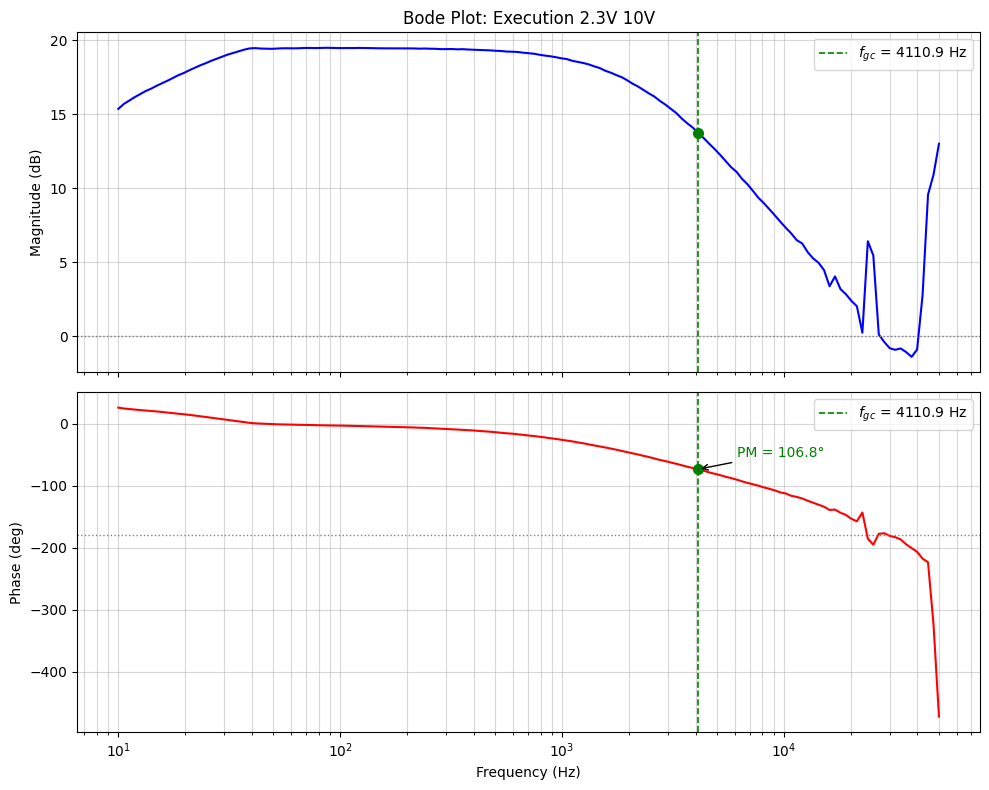

Crossover Frequency : 4110.9179 Hz
Magnitude at wgc    : 13.7132 dB
Phase at wgc        : -73.1614 deg
Phase Margin        : 106.8386 deg


In [7]:
freq_crossover, mag_crossover, phase_crossover = plot_bode('2_3_V_10V', wgc, title="Bode Plot: Execution 2.3V 10V")

In [8]:
kp = -mag_crossover # in decibels
print(f"kp = {kp:.2f} dB")
anticipated_phase = phase_crossover - 90
p_boost = phase_margin-180-anticipated_phase
print(f"Anticipated phase with integrator: {anticipated_phase:.2f} deg")
print(f"Required phase boost for phase margin: {phase_margin-180-anticipated_phase:.2f} deg")
k = np.tan(np.deg2rad(p_boost/2 + 45))
print(f"k = {k:.2f}")
wi = wc = wgc

kp = -13.71 dB
Anticipated phase with integrator: -163.16 deg
Required phase boost for phase margin: 43.16 deg
k = 2.31


In [9]:
linear_kp = np.power(10, kp / 20)
gco = linear_kp * 2*np.pi*wi * np.sqrt((1+k**-2)/(1+k**2))
print(gco)

2338.4780913446416


In [10]:
rf1 = 4300
cc1 = 1/(rf1*gco)
cc2 = cc1/k**2
Vo = 10
rf2 = rf1 * 2.5/(Vo - 2.5)
wc_rad = 2*np.pi*wc
print(wc_rad)
rc1 = 1/(wc_rad*np.sqrt(cc1*cc2))

print("\nTHEORETICAL VALUES")
print(f"rf1 = {rf1*1e-3:.2f} kOhm")
print(f"cc1 = {cc1*1e6:.2f} uF")
print(f"cc2 = {cc2*1e9:.2f} nF")
print(f"rf2 = {rf2*1e-3:.2f} kohm")
print(f"rc1 = {rc1*1e-3:.2f} kohm")

print(f"gco: {1/(rf1*cc1):.2f}")

# reassigning for actual values
cc1 = 0.1e-6
cc2 = 22e-9
rf2 = 1.5e3
rc1 = 820
print("\nREAL VALUES")
print(f"rf1 = {rf1*1e-3:.2f} kOhm")
print(f"cc1 = {cc1*1e6:.2f} uF")
print(f"cc2 = {cc2*1e9:.2f} nF")
print(f"rf2 = {rf2*1e-3:.2f} kohm")
print(f"rc1 = {rc1*1e-3:.2f} kohm")

print(f"back-calculated gco: {1/(rf1*cc1):.2f}")

26179.938779914944

THEORETICAL VALUES
rf1 = 4.30 kOhm
cc1 = 0.10 uF
cc2 = 18.66 nF
rf2 = 1.43 kohm
rc1 = 0.89 kohm
gco: 2338.48

REAL VALUES
rf1 = 4.30 kOhm
cc1 = 0.10 uF
cc2 = 22.00 nF
rf2 = 1.50 kohm
rc1 = 0.82 kohm
back-calculated gco: 2325.58


#### PLECS
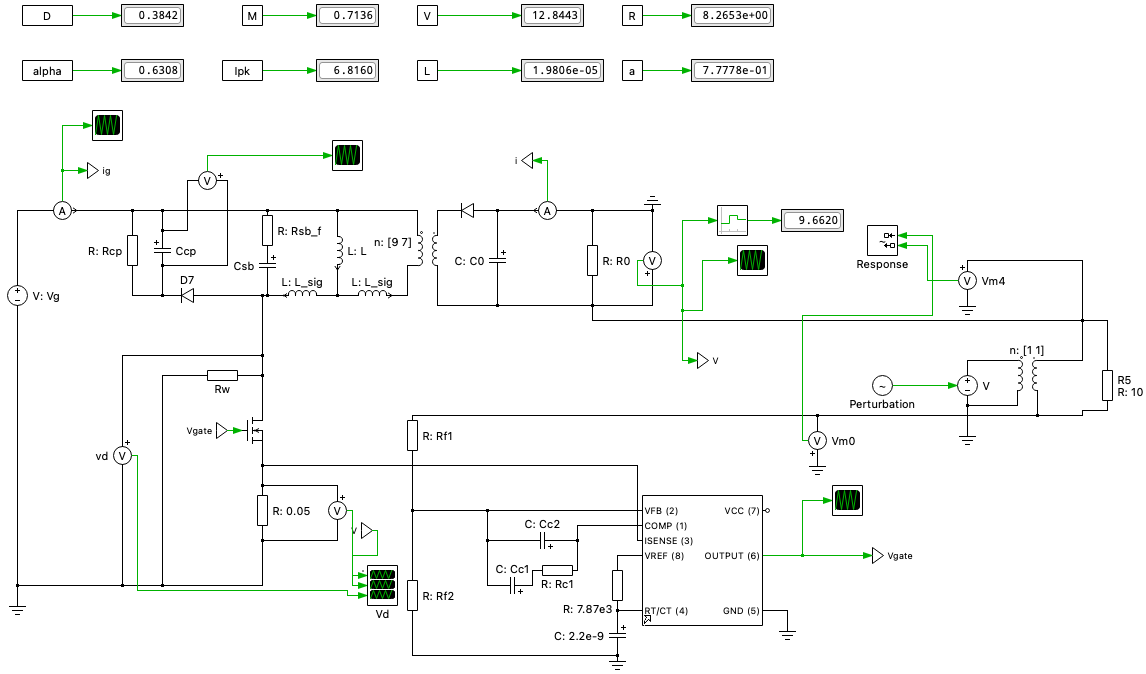
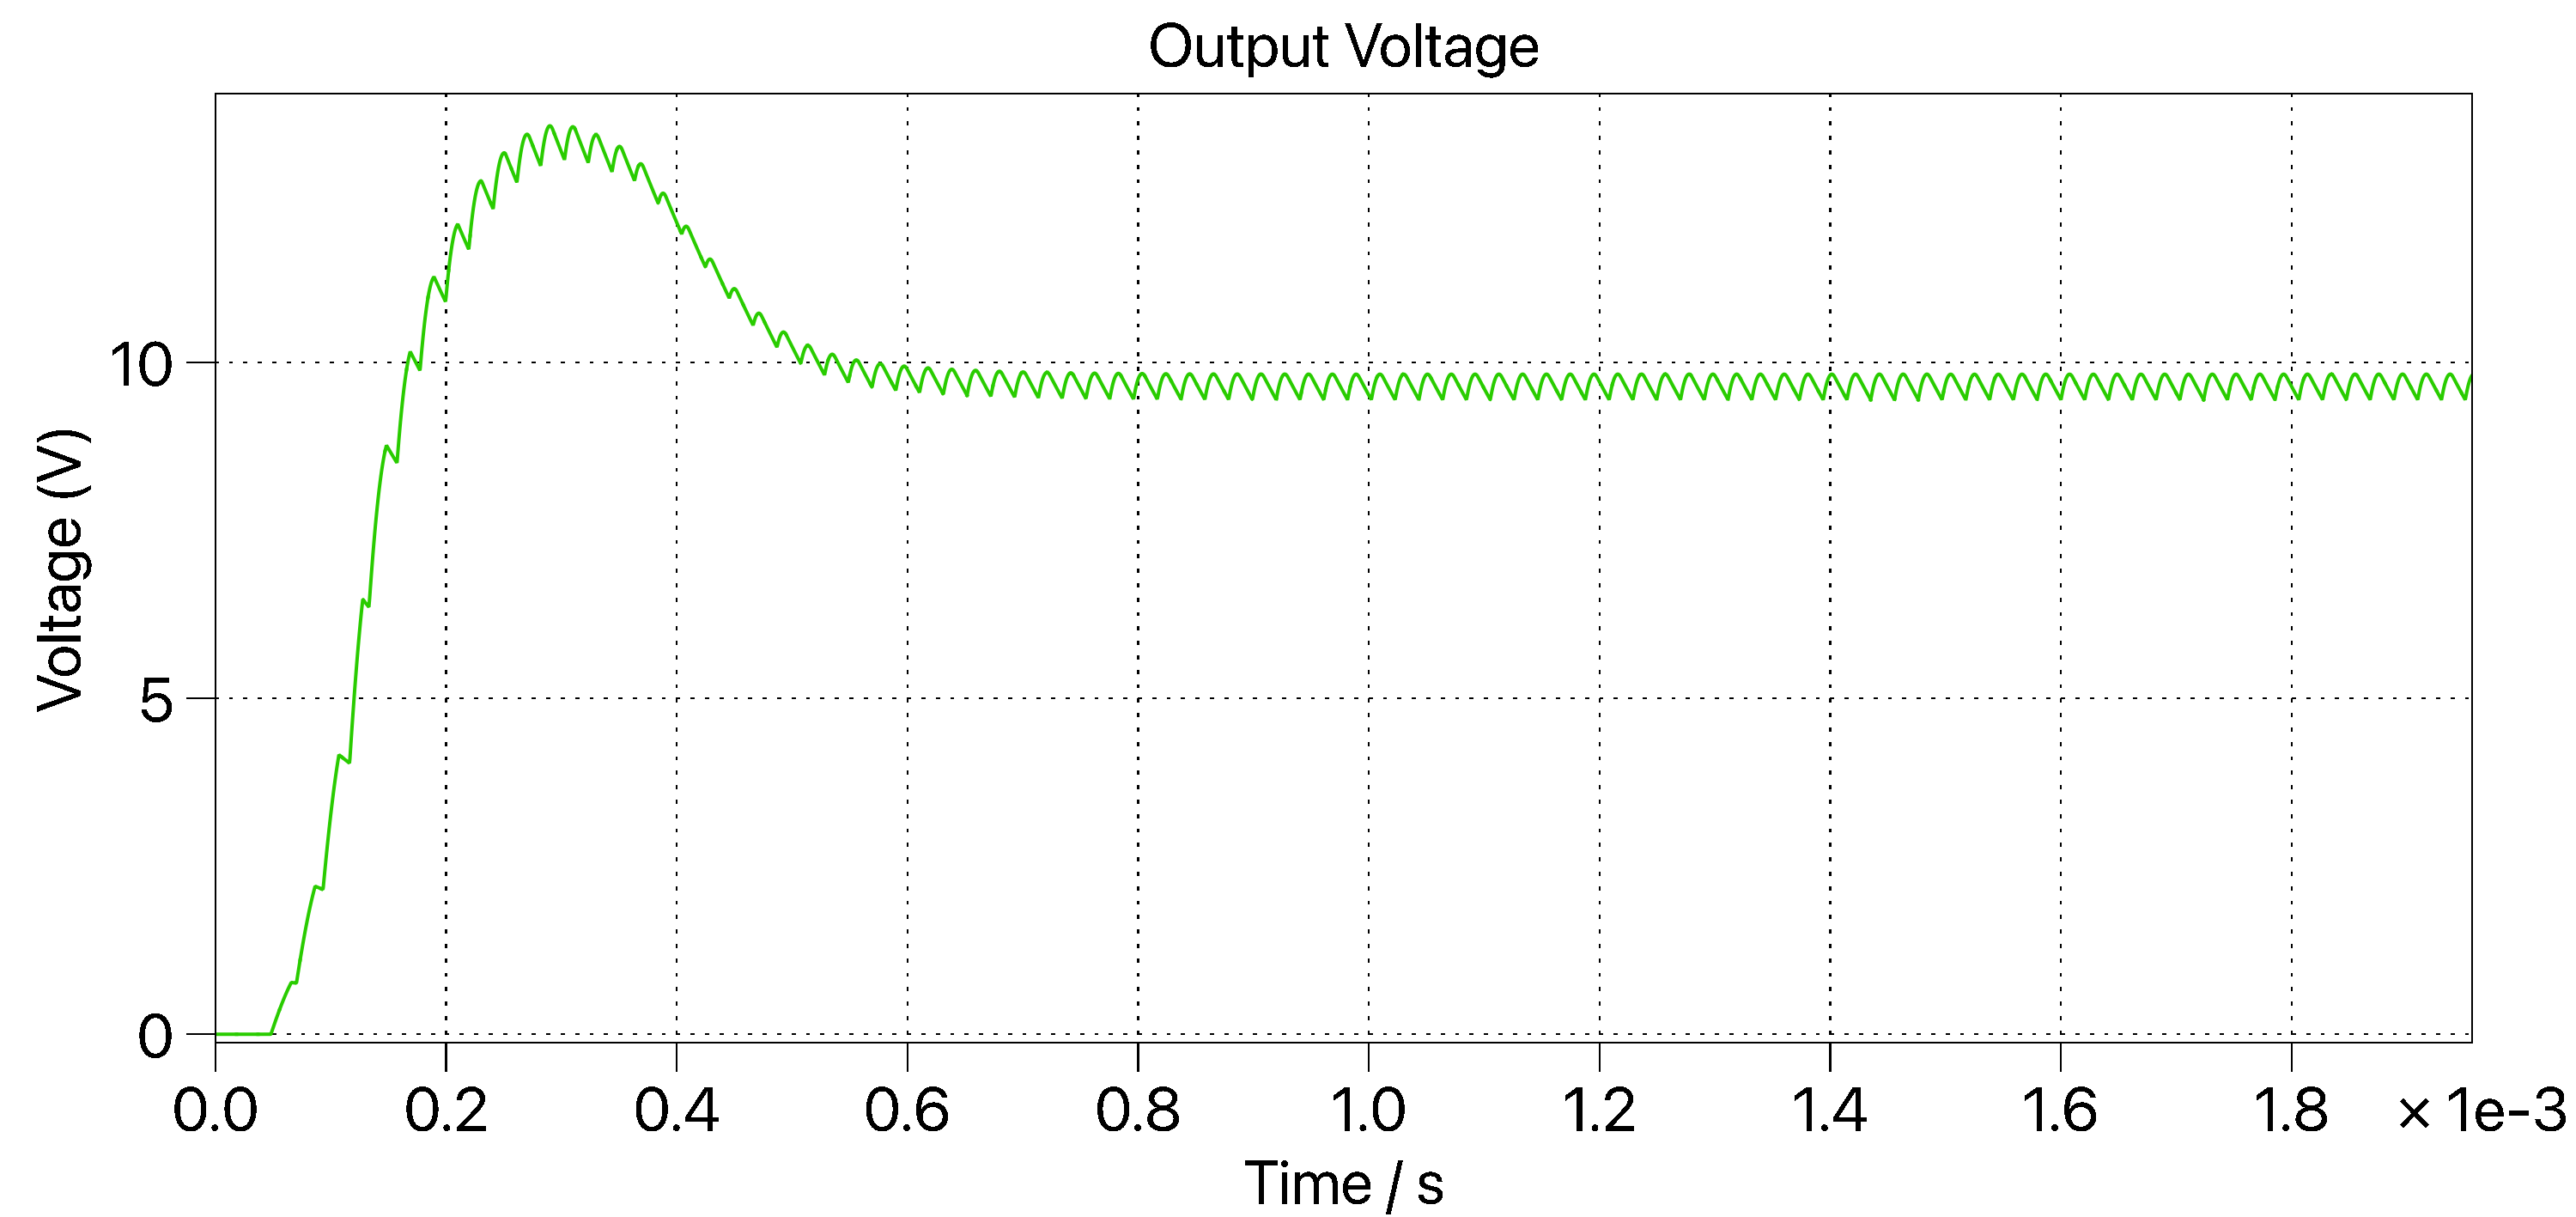
The time-domain output voltage shows that the damping is somewhat less than .7 but is around there. The output settles around 10V.

## Lab 10
Amanda Chang

In [16]:
import pandas as pd
import csv
import math
import matplotlib.pyplot as plt3
from scipy.stats import linregress
from scipy.signal import find_peaks
import numpy as np
pd.set_option('display.float_format', lambda x: '%e' % x)

TITLE_FONTSIZE = 14
AXES_FONTSIZE = 12

def read_rigol_csv(csv_file_name):
    with open(csv_file_name) as f:
        rows = list(csv.reader(f))

    i = 0
    while rows[0][i] != "":
        i = i + 1

    numcols = i - 2
    t0 = float(rows[1][numcols])
    dT = float(rows[1][numcols+1])

    data = pd.read_csv(csv_file_name, usecols=range(0, numcols), skiprows=[1])
    data['X'] = t0 + data['X'] * dT

    return data, t0, dT
    
def get_channel_data(data, channel_name):
    if channel_name in data.columns:
        return data[channel_name].rolling(10, min_periods=1, center=True).mean()
        #return data[channel_name]
    return None

def analyze_rigol_data(data, has_ch1, has_ch2, x1, x2, drainx):
    slope, ch2_mean, peak_vsh, max_vdrain = None, None, None, None
    
    if x1 is not None and x2 is not None:
        subset = data[(data['X'] >= x1) & (data['X'] <= x2)]
        
        if has_ch1 and not subset.empty:
            result = linregress(subset['X'], subset['CH1'])
            slope = float(result.slope)
            peak_vsh = float(data.iloc[(data['X'] - x2).abs().argsort()[:1]]['CH1'].values[0])

        if has_ch2:
            ch2_mean = float(subset['CH2'].mean())
            max_vdrain = data.iloc[(data['X'] - drainx).abs().argsort()[:1]]['CH2'].item()
    elif has_ch2:
        max_vdrain = data.iloc[(data['X'] - drainx).abs().argsort()[:1]]['CH2'].item()
            
    return slope, ch2_mean, peak_vsh, max_vdrain

def plot_rigol(
    filepath, 
    title, 
    ch1label="Shunt Voltage (Vsh)", 
    ch2label="Drain Voltage (Vd)", 
    ch3label="Cathode Voltage (Vk)", 
    x1=None, 
    x2=None, 
    duty_points=None, 
    drainx=0.5e-5
): 
    data, t0, dT = read_rigol_csv(f"data/{filepath}.csv")
    
    channels = {
        'CH1': {'label': ch1label, 'color': '#0072BD', 'axis': 0},
        'CH2': {'label': ch2label, 'color': '#f74519', 'axis': 1},
        'CH3': {'label': ch3label, 'color': '#FFBF00', 'axis': 1}
    }

    for ch in channels:
        smoothed = get_channel_data(data, ch)
        if smoothed is not None:
            data[ch] = smoothed

    slope, ch2_mean, peak_vsh, max_vdrain = analyze_rigol_data(
        data, 'CH1' in data, 'CH2' in data, x1, x2, drainx
    )

    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax2 = ax1.twinx()
    axes = [ax1, ax2]
    
    handles, labels = [], []

    for ch, config in channels.items():
        if ch not in data:
            continue
            
        ax = axes[config['axis']]
        ln, = ax.plot(data['X'], data[ch], label=config['label'], color=config['color'], alpha=0.9)
        
        handles.append(ln)
        labels.append(config['label'])

    if 'CH1' in data and x1 is not None and x2 is not None:
        subset = data[(data['X'] >= x1) & (data['X'] <= x2)]
        fit = slope * subset['X'] + (peak_vsh - slope * x2)
        ax1.plot(subset['X'], fit, color="red", lw=2, ls="--", label='Linear Fit')
        ax1.plot(x2, peak_vsh, 'r*', markersize=10)

    if 'CH2' in data and duty_points is not None:
        for px in duty_points:
            idx = (data['X'] - px).abs().idxmin()
            py = data.loc[idx, 'CH2']
            ax2.plot(px, py, 'go', mfc='none', markersize=8)

    ax1.set_xlabel("Time (s)", fontsize=AXES_FONTSIZE)
    ax1.set_ylabel(ch1label, color=channels['CH1']['color'], fontsize=AXES_FONTSIZE)
    
    if 'CH3' in data:
        ax2.set_ylabel(f"{ch2label} / {ch3label}", color='#FB820D', fontsize=AXES_FONTSIZE)
    else:
        ax2.set_ylabel(f"{ch2label}", color=channels['CH2']['color'], fontsize=AXES_FONTSIZE)
    
    ax1.legend(handles, labels, loc='upper left', frameon=True)
    plt.title(title, fontsize=TITLE_FONTSIZE)
    plt.tight_layout()
    plt.show()
    return (slope, ch2_mean, peak_vsh, max_vdrain)

### Q1: Take and save a baseline Vsh/Vdrain measurement.

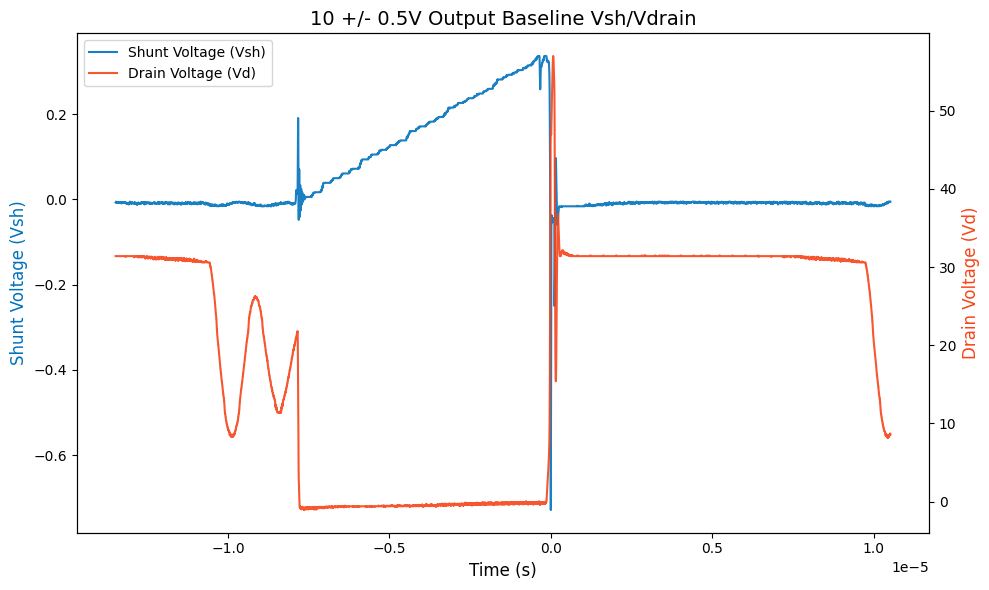

In [17]:
_ = plot_rigol("q1_9_72v", "10 +/- 0.5V Output Baseline Vsh/Vdrain")

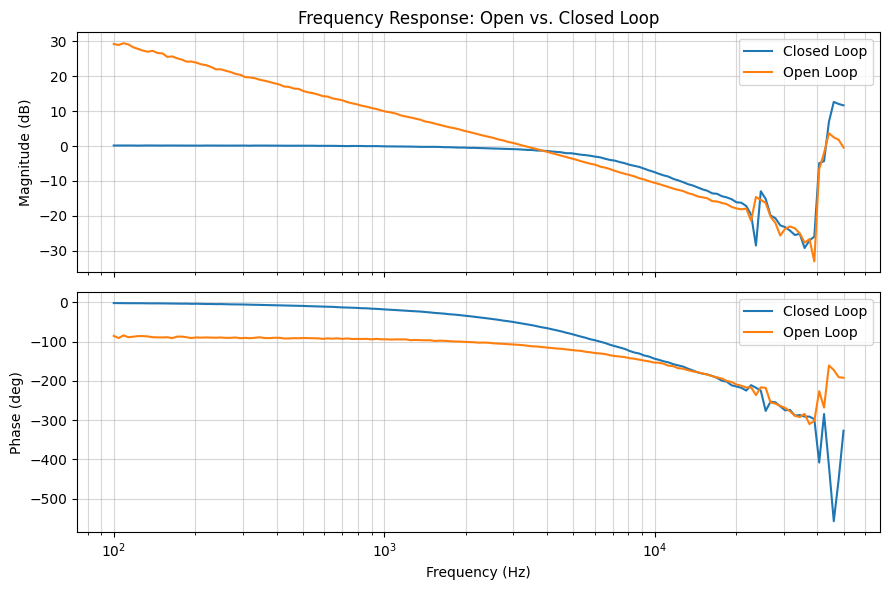

In [12]:
def plot_combined_bode(filenames, labels, title="Combined Bode Plot", TF=False):
    """
    Plots multiple Bode datasets onto a single set of axes for comparison.
    filenames: List of strings (e.g., ['1_7_V_5V', ...])
    labels: List of strings for the legend (e.g., ['5V', '7V', '10V'])
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

    for filename, label in zip(filenames, labels):
        df = process_digilent(filename)
        
        freq = df['Frequency (Hz)']
        mag = df['Channel 2 Magnitude (dB)']
        phase = df['Channel 2 Phase (deg)']
        
        ax1.semilogx(freq, mag, label=label, linewidth=1.5)

        phase_unwrapped = np.rad2deg(np.unwrap(np.deg2rad(phase)))
        ax2.plot(freq, phase_unwrapped, label=label, linewidth=1.5)

    ax1.set_ylabel('Magnitude (dB)')
    ax1.set_title(title)
    ax1.grid(True, which="both", ls="-", alpha=0.5)
     

    ax2.set_xlabel('Frequency (Hz)')
    ax2.set_ylabel('Phase (deg)')
    ax2.grid(True, which="both", ls="-", alpha=0.5)
    

    if TF:
        denom = [(R*C)/2, 1]
        tf = signal.TransferFunction([9.388], denom)
    
        w = np.logspace(1.8, 5.5, 1000)
        w, mag, phase = signal.bode(tf,w)
        ax1.semilogx(w/(2*np.pi), mag, label="Custom LPF")
        ax2.semilogx(w/(2*np.pi), phase, label="Custom LPF")
    ax1.legend()
    ax2.legend()
    plt.tight_layout()
    plt.show()

files_to_compare = ['closedloop', 'openloop']
voltage_labels = ['Closed Loop', 'Open Loop']

plot_combined_bode(files_to_compare, voltage_labels, title="Frequency Response: Open vs. Closed Loop")

### 1. Analyze the open-loop TF measurement:

#### Q2: Plot the GOL(s) Bode plot (channel 2 magnitude and phase).

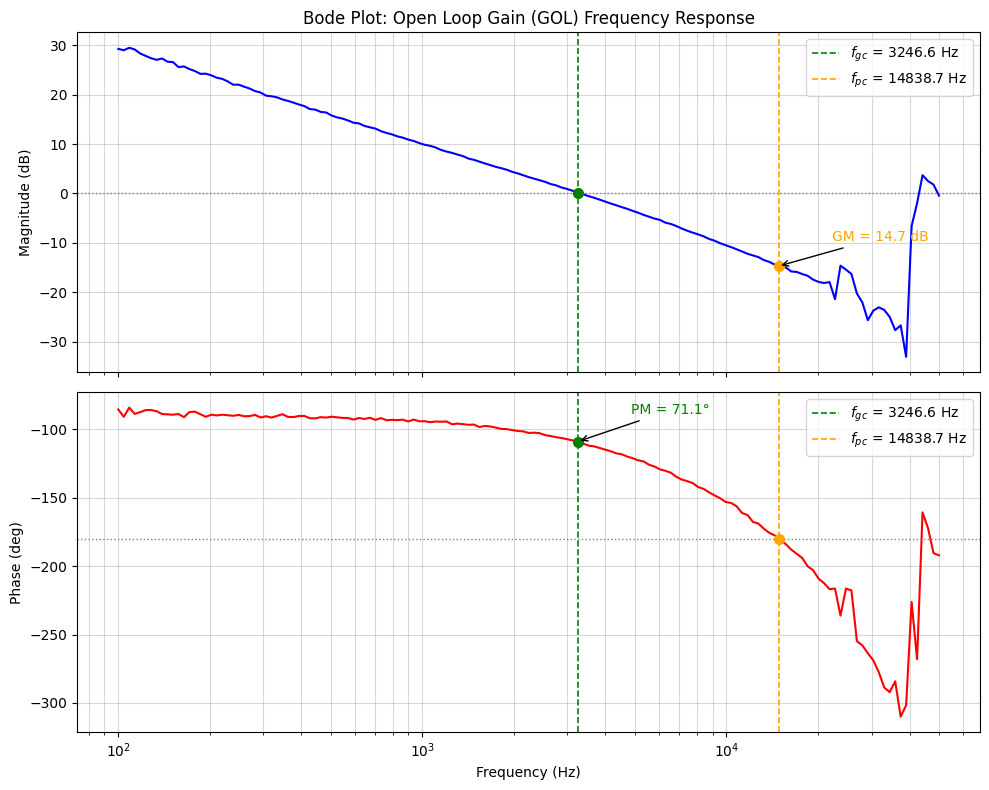

Crossover Frequency : 3246.5583 Hz
Magnitude at wgc    : 0.1552 dB
Phase at wgc        : -108.9223 deg
Phase Margin        : 71.0777 deg
Phase Crossover Freq: 14838.7464 Hz
Gain Margin         : 14.7263 dB


In [13]:
openloopresult = plot_bode('openloop', gain_margin=True, wgc=None, title="Bode Plot: Open Loop Gain (GOL) Frequency Response"
                          )
freq_crossover_ol, mag_crossover_ol, phase_crossover_ol, gain_margin_phase, co_gain_margin_db = openloopresult

#### Q3: Determine the cross-over frequency, phase margin and gain margin. Are the requirements met?
The crossover frequency is 3247Hz, which is somewhat low in comparison to our goal frequency of 4167Hz (more than 20% lower). However, this does mean that the frequency is slow enough to definitely avoid incorporating switching noise, which was the purpose of dividing the original 50kHz by 8 in the first place. The phase margin is sufficiently above 60° at 71°, and the gain margin, calculated based on where the phase crosses -180 degrees (at 14.83kHz), is quite high (14.73 dB) indicating stability. In short, all requirements are met but the crossover frequency could stand to be a bit higher.
#### Q4: What does the low frequency magnitude and phase-shift correspond to?
There is high gain at low frequencies and a relatively stable ~-110° of phase-shift. This high gain at low frequencies means that the gain at DC is extremely high, which is desired in this case. This is because the behavior at lower frequencies is coming from the integrator in my type II compensator, which has a transfer function of 1/s and thus a theoretical gain of $\inf$ at DC. This is what guarantees zero steady-state error. Infinite DC gain forces the loop to correct any constant output voltage error. The ~−110° phase shift at low frequencies is the sum of the −90° contributed by the integrator and an additional ~−20° of phase lag from various factors in the real design of it, like the output capacitance and load resistance.
#### Q5: What can you predict in terms of the stability and performance of the closed-loop control?
It seems like the closed loop controller will be stable since both the phase margin and the gain margin are positive and well above the threshold values for stability (71° and 14.73dB respectively, as mentioned before). The gain crosses the 0dB line well before the phase crosses the -180° line, which is a hallmark for a stable system.

### 2. Analyze the closed-loop TF measurement:
#### Q6: Plot the G(s) Bode plot (channel 2 magnitude and phase).

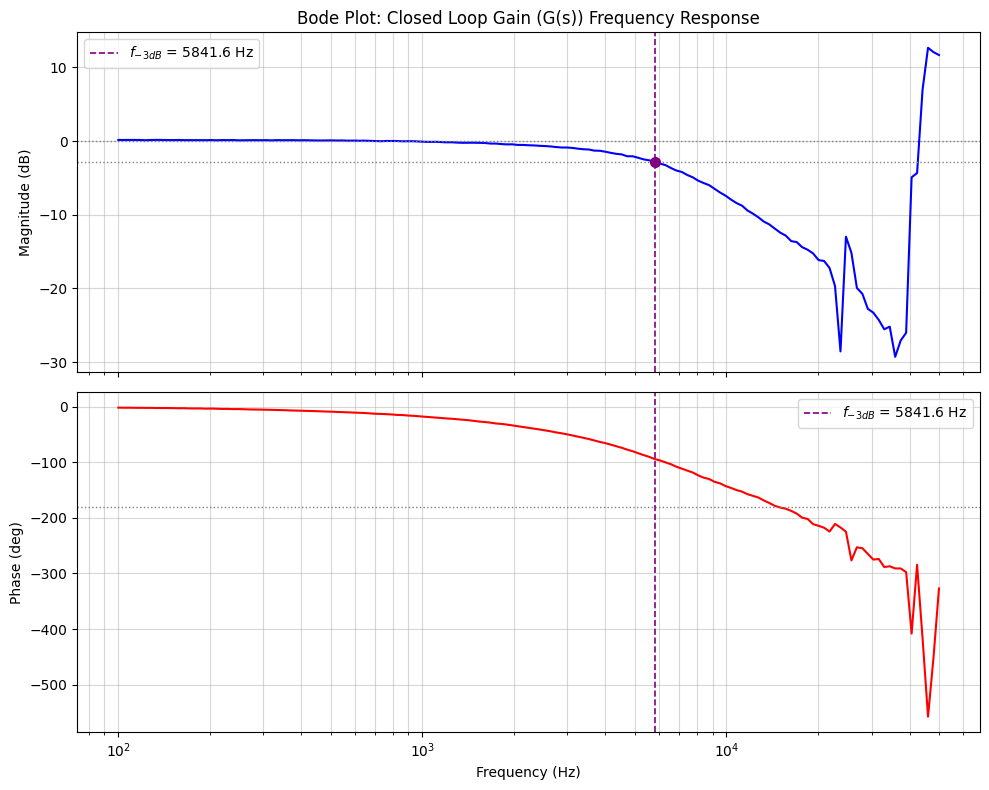

Closed-loop -3dB cutoff : 5841.5532 Hz


In [40]:
cutoff_freq = plot_bode_cutoff('closedloop', title="Bode Plot: Closed Loop Gain (G(s)) Frequency Response")

#### Q7: Does the TF reasonably resemble a second order system? Why?
Maybe? The TF looks sort of like a second-order low-pass filter since the slope of the magnitude dropoff seems to be approximately -40db/decade past the cutoff frequency (if you project out over the noisy portion of the magnitude signal) and there is more than 90 degrees of phase shift. It seems like my two poles are very close together, since the dropoff seems even.
#### Q8: What is the cut-off frequency and bandwidth of the closed-loop control? Are the requirements met?
The closed-loop −3 dB bandwidth is 5841.5 Hz, compared to the target of 6250 Hz (f_sw/8). This is within 6.5% of the specification, which is well within acceptable tolerance given real component values. The 1.5× relationship between the open-loop crossover frequency (3247 Hz) and the closed-loop bandwidth (5842 Hz) confirms the design assumption used in the K-factor method held in practice.

#### Q9: What does the Bode plot suggest about the damping of the closed-loop system? Estimate the damping ratio from the shape of the transfer function.
From the bode plot, it seems like the system is damped well. At low frequencies, the magnitude sits at 0dB and rolls off in a very typical low-pass filter shape. The absence of any magnitude peaking near the cutoff frequency indicates ζ > 1/sqrt(2), which is about 0.707.

#### Q10: Does the damping ratio fit with the measured phase margin?
A phase margin of 71.1 degrees, from the open loop gain plot, corresponds to a damping ratio of approximately ζ = 0.71. This is consistent with the closed-loop Bode plot, which shows no magnitude peaking and therefore seems to line up with that greater than 0.7 estimate.

### 3. Analyze the step-response:

#### Q11: Plot the step response measurements (get channels 1 & 2 to overlay nicely by applying an appropriate offset to channel 2).

% Overshoot: 2.55
Zeta: 0.7595


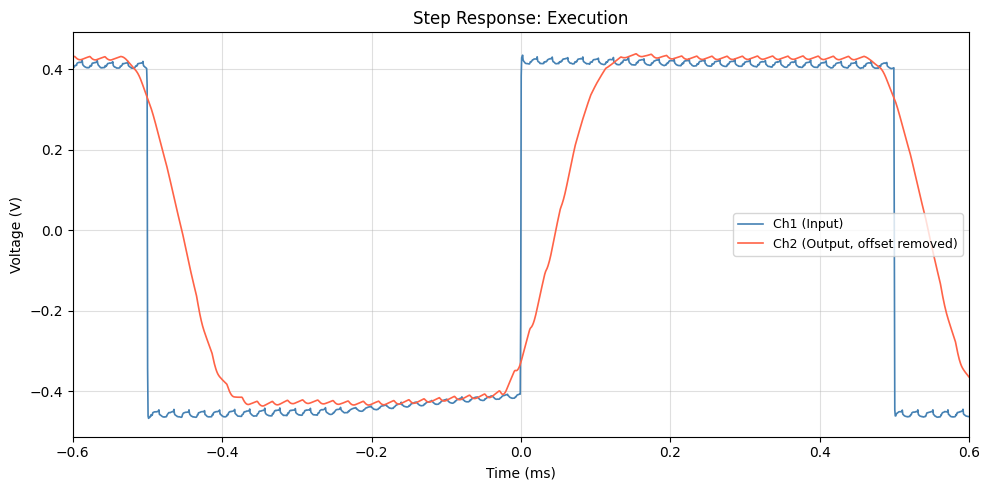

In [52]:
def plot_step_response(filename, title="Step Response"):
    df = process_digilent(filename)
    df.columns = df.columns.str.strip()

    time = df['Time (s)'] * 1e3
    ch1  = df['Channel 1 (V)']
    ch2  = df['Channel 2 (V)'] + 9.79     # remove hardware offset to overlay
    ch2 = ch2.rolling(max(3, int(len(ch2) * 0.02)) | 1, center=True, min_periods=1).mean()

    overshoot = max(ch2)
    desired = max(ch1)

    overshoot_pct = (overshoot - desired) / desired * 100
    print(f"% Overshoot: {overshoot_pct:.2f}")

    # damping ratio from overshoot: zeta = -ln(OS) / sqrt(pi^2 + ln(OS)^2)
    if overshoot_pct > 0:
        ln_os = np.log(overshoot_pct / 100)
        zeta  = -ln_os / np.sqrt(np.pi**2 + ln_os**2)
    else:
        zeta = 1.0
    print(f"Zeta: {zeta:.4f}")

    # --- plot ---
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(time, ch1,  color='steelblue', linewidth=1.2, label='Ch1 (Input)')
    ax.plot(time, ch2,  color='tomato',    linewidth=1.2, label='Ch2 (Output, offset removed)')

    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Voltage (V)')
    ax.set_xlim(-0.6, 0.6)
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(True, which='both', ls='-', alpha=0.4)
    plt.tight_layout()
    plt.show()

plot_step_response('stepresponsescope', title="Step Response: Execution")

#### Q12: Estimate the step response overshoot.
The overshoot is about 2.55%, based on the peak value of the output and the actual value it's trying to reach after moving average filtering (Based on ch1).

#### Q13: Estimate the damping ratio from the amount of overshoot and determine damping ratio.
$$\zeta = \frac{-\ln(PO/100)}{\sqrt{\pi^2 + \ln(PO/100)^2}}$$
We can calculate the damping ratio from the above equation, which yields us a zeta of 0.7595.

### 4. Final observations

#### Q14: Do the three types of measurement tell us the same story about the performance of the closed-loop control? Elaborate.
I think the measurements seem to tell a relatively similar story about the performance of the closed-loop control. Each of the plots shows that the zeta is about 0.7 or a bit above. They are all slightly underdamped and in the desired 0.7 zone.
#### Q15: Could your controller design be improved? In what respect?
I think my closed-loop gain could be improved by increasing the crossover frequency. This could be potentially done by reducing my Rc1 since Rc1 is inversely related to crossover frequency.

### Independent Steps
1. I've noticed this across almost all of the lab pdfs, but when I copy the prompts from the pdf, it turns every ti into a 7 and puts the letter label at the end instead of the beginning. I wonder if you could try a different PDF exporter than whichever one you're currently using or try running Acrobat OCR on existing pdfs it to fix that? This is what a direct copy paste of Q12 and Q13 from this lab looks like, for instance:
```
Q12: Es7mate the step response overshoot.B.
Q13: Es7mate the damping ra7o from the amount of overshootC.
and determine damping ra7o.
```
2. General class feedback: Really loved this course and the amount of truly useful knowledge and theoretical gap filling you've facilitated. However, the workload towards the end of the semester felt much higher than at the beginning, and I found it to be a monumental amount of commitment to do all of the work for this lab and the last and also try to invest time into the final project, especially since other courses/projects tend to also ramp up around this time. It would be made much better by not having labs and the project at the same time. I seem to remember the early sim labs being much lower workload than this section of the course, so maybe compressing labs 1 and 2 into one lab and cutting a little bit and giving more breathing room at the end would be better, or even cutting a lab entirely would make learning less stressful and allow for more exploration into the final topics.